In [2]:
import os

#analysis
import numpy as np
import cooler 
import cooltools
import pandas as pd
import bioframe
from functools import reduce

#plotting
import matplotlib.pyplot as plt
from matplotlib import colors
from cooltools.lib import plotting
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
import seaborn as sns

%cd /home/varshini/uc_analyses/
import utils, matchmaker_functions
%cd /home/varshini/LoopCall_Analysis_Scripts

# plot formatting
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True

plt.rcParams['axes.grid'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams.update({'font.size': 18})

plt.rcParams["legend.frameon"] = False

/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


/home/varshini/microc_analyses/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
basedir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/loops_anchors/'

lc_fname = 'merged_calls_125kb_q0.01_classes_new.txt'
loop_classes = pd.read_csv(os.path.join(basedir, lc_fname), sep='\t')
loop_classes[['start1','start2']] = loop_classes[['start1','start2']] - 1
ls_fname = 'able_scores_125kb_q0.012000bp_wavg.tsv'
#ls_fname = 'oe_scores_2000bp.tsv'

loop_strengths = pd.read_csv(os.path.join(basedir, ls_fname), sep='\t',
                            names=['chr1','start1','end1','chr2','start2','end2','FDR',
                                    'strength_P1','strength_P2', 'strength_P3']).drop('FDR',axis=1)
loop_strengths['anchor1']=loop_strengths[['start1','end1']].mean(axis=1)
loop_strengths['anchor2']=loop_strengths[['start2','end2']].mean(axis=1)

savedir = os.path.join('/mnt/md0/varshini/Analysis/Blood/figs_v2/fig1/')

In [4]:
loop_strengths.dropna(subset=['strength_P1','strength_P2','strength_P3'])

,chr1,start1,end1,chr2,start2,end2,strength_P1,strength_P2,strength_P3,anchor1,anchor2
0,chr1,5990000,5995000,chr1,6197000,6202000,0.009737,0.011958,0.012801,5992500.0,6199500.0
1,chr1,5991000,5996000,chr1,6024000,6029000,0.159733,0.066635,0.047155,5993500.0,6026500.0
2,chr1,6039000,6044000,chr1,6242000,6247000,0.003750,0.018519,0.014596,6041500.0,6244500.0
3,chr1,6050000,6055000,chr1,6242000,6247000,0.007929,0.023526,0.018890,6052500.0,6244500.0
4,chr1,6107000,6112000,chr1,6169000,6174000,0.200848,0.101511,0.042473,6109500.0,6171500.0
...,...,...,...,...,...,...,...,...,...,...,...
63722,chrX,152950000,152955000,chrX,153730000,153735000,0.004008,0.007830,0.002661,152952500.0,153732500.0
63723,chrX,152950000,152955000,chrX,153950000,153955000,0.011237,0.015639,0.015908,152952500.0,153952500.0
63724,chrX,152950000,152955000,chrX,154310000,154315000,0.005005,0.002911,0.004418,152952500.0,154312500.0
63725,chrX,153545000,153550000,chrX,154535000,154540000,0.012135,0.009459,0.006276,153547500.0,154537500.0


In [5]:
loop_classes

,seqnames1,start1,end1,annotation1,seqnames2,start2,end2,annotation2,pair
0,chr1,5990000,5995000,P,chr1,6197000,6202000,P,P-P
1,chr1,5991000,5996000,P,chr1,6024000,6029000,P,P-P
2,chr1,6039000,6044000,P,chr1,6242000,6247000,P,P-P
3,chr1,6050000,6055000,Null,chr1,6242000,6247000,P,P-Null
4,chr1,6107000,6112000,CTCF,chr1,6169000,6174000,Null,CTCF-Null
...,...,...,...,...,...,...,...,...,...
63724,chrX,152950000,152955000,Null,chrX,154310000,154315000,Null,Null-Null
63725,chrX,153545000,153550000,Null,chrX,154535000,154540000,P,P-Null
63726,chrX,153740000,153745000,Null,chrX,154540000,154545000,P,P-Null
63727,chrX,155640000,155645000,Null,chrX,155955000,155960000,Null,Null-Null


In [63]:
## functions

def loop_strength_by_distance(merged_loops, dist_range, col1, col2=None, 
                              tstr='loop strengths by distance', sd=None, ylim=(0,0.13)):
    plt.figure()
    custom_colors = {'E-P':'#33BBEE',
                'CTCF-CTCF':'#CC3311',
                'E-E':'#009988',
                'P-P':'#0099BB',
                'E-CTCF':'#EE3377',
                'P-CTCF':'#EE7733',
                'E-Null':'#3377EE',
                'P-Null':'#008899',
                'CTCF-Null':'#CC1133',
                'Null-Null':'#BBBBBB'}

    merged_loops['color'] = merged_loops['pair'].map(custom_colors)
    legend_elements = [
    Patch(facecolor=color, label=label) for label, color in custom_colors.items()
     ]
    for pair in merged_loops['pair'].unique():
        merged_loops_sub = merged_loops[merged_loops['pair']==pair]
        toplot =[]
        for i, dist in enumerate(dist_range):
            if i == len(dist_range)-1:
                merged_loops_dist = merged_loops_sub[(abs(merged_loops_sub['start1']-merged_loops_sub['start2'])>dist)]
            else:
                merged_loops_dist = merged_loops_sub[(abs(merged_loops_sub['start1']-merged_loops_sub['start2'])>dist)
                                                    & (abs(merged_loops_sub['start1']-merged_loops_sub['start2'])<dist_range[i+1])]
            if col2 is None:
                med = merged_loops_dist.loc[:,f"strength_{col1}"]
            else:
                med = merged_loops_dist.loc[:,f"strength_{col1}"].divide(merged_loops_dist.loc[:,f"strength_{col2}"])
            toplot.append(med.median())
        plt.scatter([d//1000 for d in dist_range], toplot, color=merged_loops_dist['color'].iloc[0])
        plt.plot([d//1000 for d in dist_range], toplot, color=merged_loops_dist['color'].iloc[0])
        plt.title(tstr)
        plt.xlabel('Genomic Separation [kb]')
        plt.ylabel('Loop Strength')
        plt.legend(handles=legend_elements, title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.ylim(ylim)
    if sd is None:
        plt.show()
    else:
        plt.savefig(sd, dpi=300)
        

def plot_ls_heatmap(merged_loops, plot_col, valrange=None, fun='median', sd=None):
    merged_loops[['anchor1', 'anchor2']] = pd.DataFrame(
    merged_loops[['annotation1', 'annotation2']].apply(lambda x: sorted(x), axis=1).tolist(),
    index=merged_loops.index
    )
    
    grouped = merged_loops.groupby(['anchor1','anchor2'])[[plot_col]].agg(fun).reset_index()

    pivot = grouped.pivot(index='anchor2', columns='anchor1', values=plot_col)
    pivot = pivot.reindex(['CTCF', 'P', 'E', 'Null'], axis=1)
    pivot = pivot.reindex(['CTCF', 'P', 'E', 'Null'], axis=0)
    upper_tri_mask = np.triu(np.ones(pivot.shape, dtype=bool), k=1)

    # For each upper-triangular cell, move value to symmetric lower-triangular cell if it exists
    for i in range(pivot.shape[0]):
        for j in range(i+1, pivot.shape[1]):
            if not pd.isna(pivot.iat[i, j]):
                # Move value pivot[i, j] to pivot[j, i]
                pivot.iat[j, i] = pivot.iat[i, j]
                pivot.iat[i, j] = np.nan
    plt.figure(figsize=(8,6))
    
    if valrange is not None:
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap=sns.color_palette("ch:start=.2,rot=-.3", as_cmap=True),
                   vmin=valrange[0], vmax=valrange[1])
    else:
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap=sns.color_palette("ch:start=.2,rot=-.3", as_cmap=True))
        
        
    plt.title(f'{fun} heatmap')
    
    if sd is None:
        plt.show()
    else:
        plt.savefig(f"{sd}{plot_col}_{fun}.svg")


## Loop classes and loop strengths

custom_colors = {'E-P':'#33BBEE',
                'CTCF-CTCF':'#EE7733',
                'E-E':'#0077BB',
                'P-P':'#33BBEE',
                'E-CTCF':'#EE3377',
                'P-CTCF':'#EE3377',
                'E-Null':'#009988',
                'P-Null':'#009988',
                'CTCF-Null':'#CC3311',
                'Null-Null':'#BBBBBB'}

In [8]:
merged_loops = loop_strengths.merge(loop_classes, how='inner', left_on=['chr1','start1','end1','chr2','start2','end2'],
                                   right_on=['seqnames1','start1','end1','seqnames2','start2','end2'])
merged_loops.rename({'class':'pair'}, inplace=True, axis=1)

        chr1     start1       end1   chr2     start2       end2  strength_P1  \
17953   chr7  137604000  137609000   chr7  137897000  137902000     0.060087   
22538  chr10   50575000   50580000  chr10   50603000   50608000     0.138816   
17161   chr7   43904000   43909000   chr7   43923000   43928000     0.040851   
16516   chr7    7679000    7684000   chr7    7759000    7764000     0.110114   
47399   chr4   86494500   86499500   chr4   87092500   87097500     0.015070   

       strength_P2  strength_P3      anchor1      anchor2 seqnames1  \
17953     0.037166     0.022739  137606500.0  137899500.0      chr7   
22538     0.082595     0.093667   50577500.0   50605500.0     chr10   
17161     0.010771     0.020974   43906500.0   43925500.0      chr7   
16516     0.094894     0.077618    7681500.0    7761500.0      chr7   
47399     0.010271     0.012003   86497000.0   87095000.0      chr4   

      annotation1 seqnames2 annotation2    pair    color  
17953        Null      chr7      

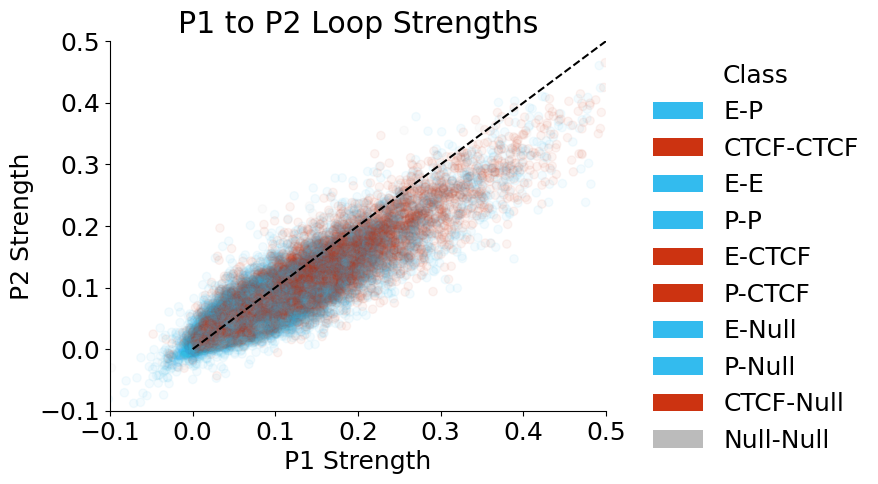

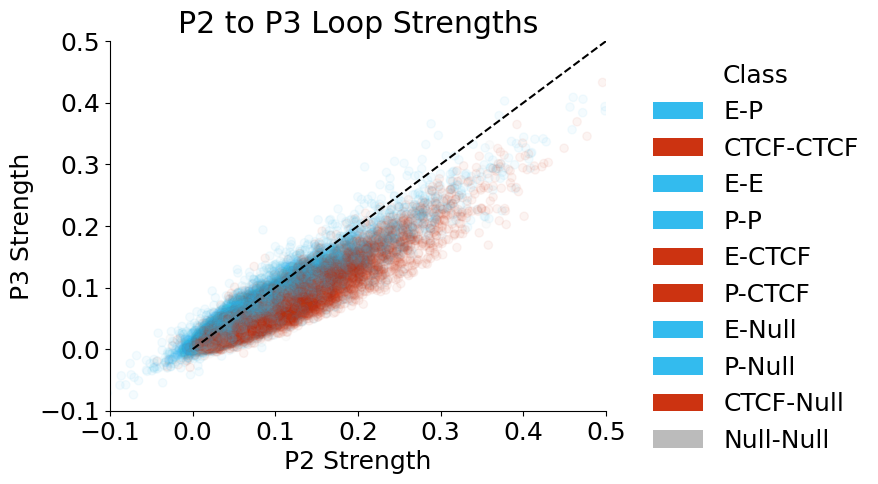

In [18]:

custom_colors = {'E-P':'#33BBEE',
                'CTCF-CTCF':'#CC3311',
                'E-E':'#33BBEE',
                'P-P':'#33BBEE',
                'E-CTCF':'#CC3311',
                'P-CTCF':'#CC3311',
                'E-Null':'#33BBEE',
                'P-Null':'#33BBEE',
                'CTCF-Null':'#CC3311',
                'Null-Null':'#BBBBBB'}
legend_elements = [
    Patch(facecolor=color, label=label) for label, color in custom_colors.items()
]

merged_loops['color'] = merged_loops['pair'].map(custom_colors)
merged_loops = merged_loops.sample(frac=1)
print(merged_loops.head())
plt.figure()
plt.scatter(merged_loops['strength_P1'], merged_loops['strength_P2'], color=merged_loops['color'], alpha=0.05, rasterized=True)
plt.plot(np.linspace(0, 1, 50), np.linspace(0, 1, 50), '--', color='k')
plt.xlim([-0.1,0.5])
plt.ylim([-0.1,0.5])
plt.title('P1 to P2 Loop Strengths')
plt.xlabel('P1 Strength')
plt.ylabel('P2 Strength')
plt.legend(handles=legend_elements, title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(os.path.join(savedir, "P1_P2_scatter.svg"))
plt.show()

plt.figure()
plt.scatter(merged_loops['strength_P2'], merged_loops['strength_P3'], color=merged_loops['color'], alpha=0.05, rasterized=True)
plt.plot(np.linspace(0, 1, 50), np.linspace(0, 1, 50), '--', color='k')
plt.xlim([-0.1,0.5])
plt.ylim([-0.1,0.5])
plt.title('P2 to P3 Loop Strengths')
plt.xlabel('P2 Strength')
plt.ylabel('P3 Strength')
plt.legend(handles=legend_elements, title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(os.path.join(savedir, "P2_P3_scatter.svg"))
plt.show()


In [53]:
savedir = os.path.join('/mnt/md0/varshini/Analysis/Blood/figs_v2/supp3/')

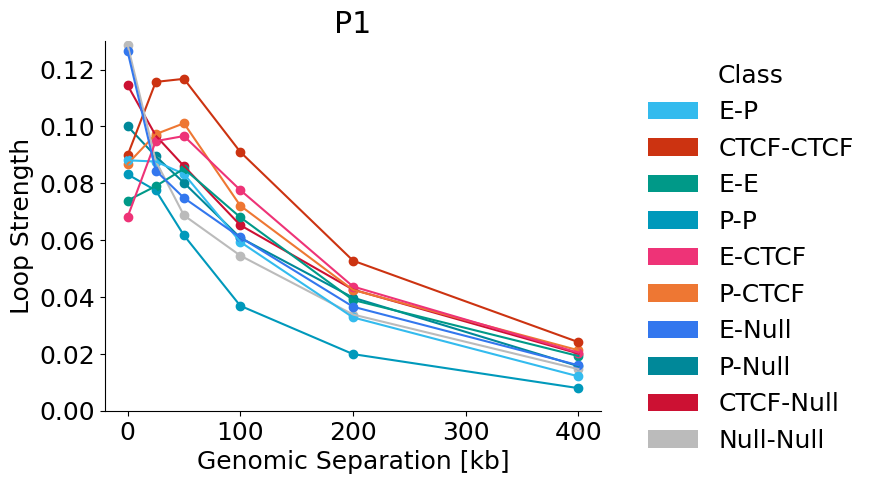

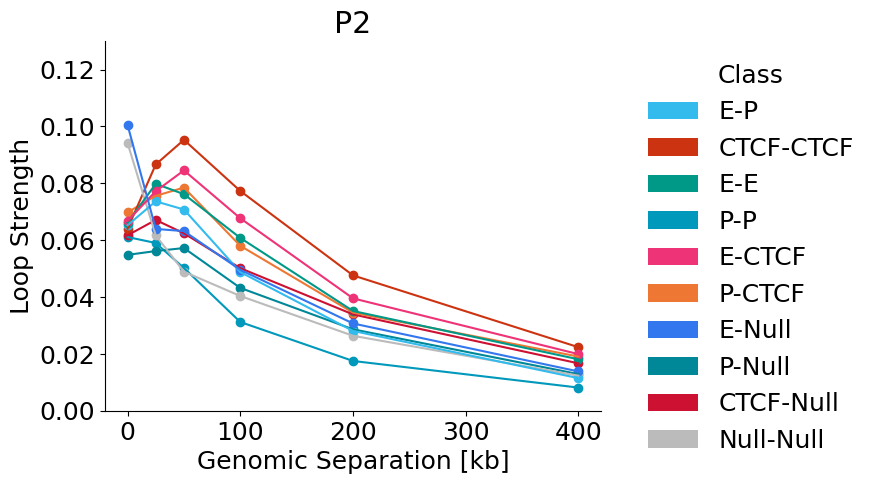

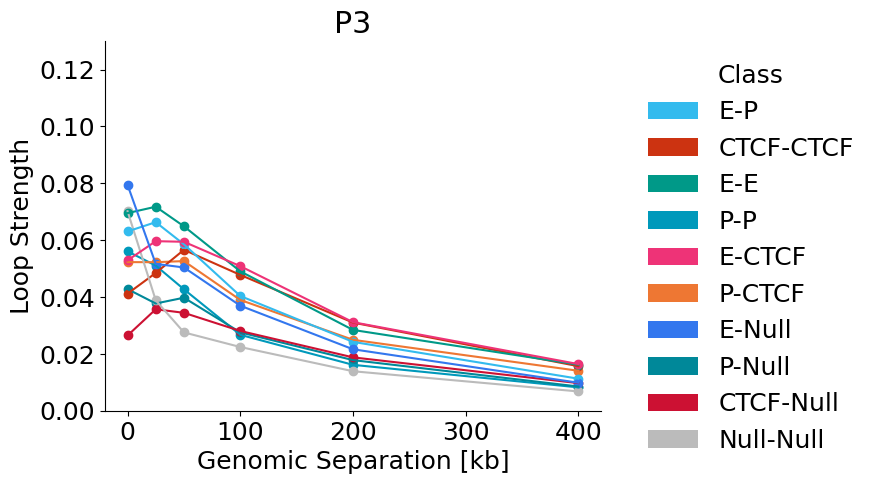

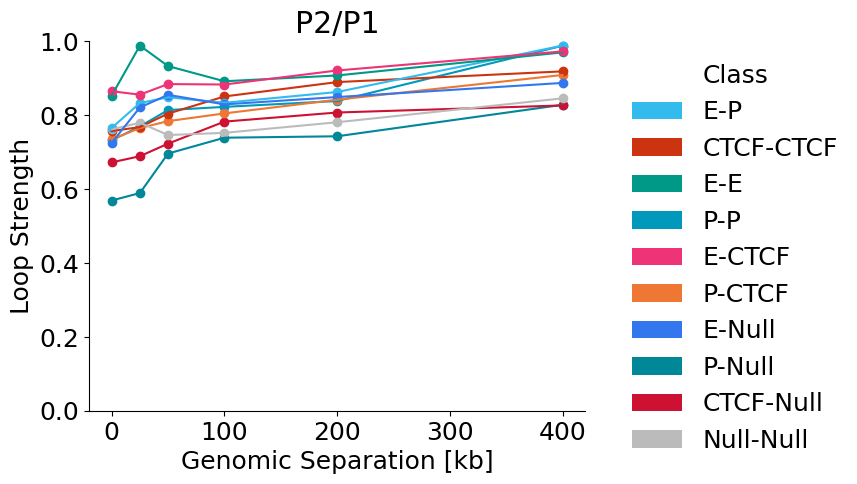

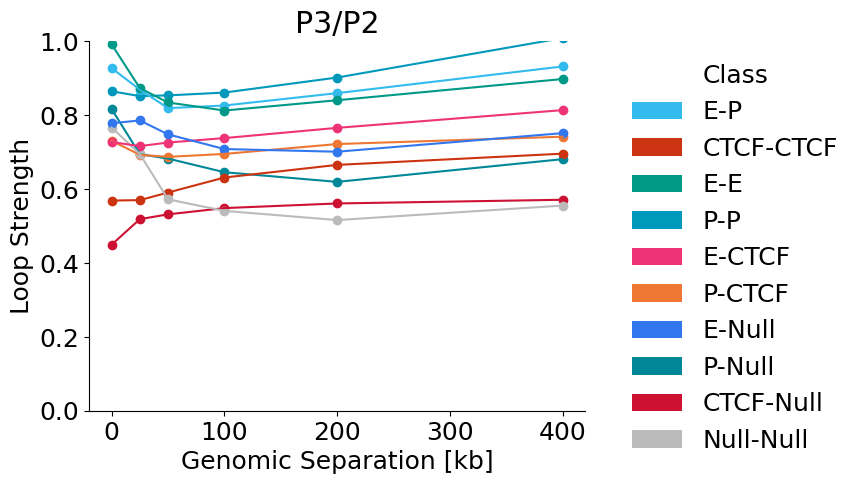

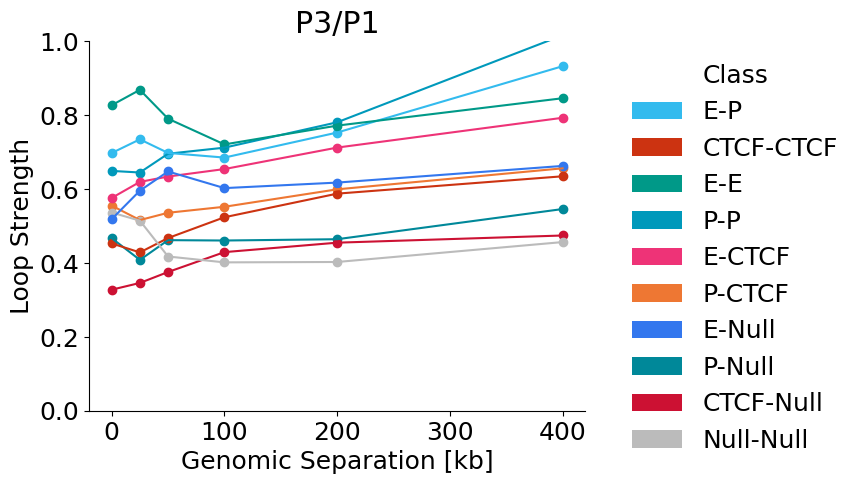

In [65]:
# loop strength as a function of distance by class

# the decrease in loop strength is distance-dependent?
# from P1 to P2, there is a distance effect. From P2 to P3, it mostly goes away

dist_range = [0, 25000, 50000, 100000, 200000, 400000]

loop_strength_by_distance(merged_loops, dist_range, col1='P1', tstr='P1', sd=os.path.join(savedir, 'loop_dist_P1.svg'))
loop_strength_by_distance(merged_loops, dist_range, col1='P2', tstr='P2',sd=os.path.join(savedir, 'loop_dist_P2.svg'))
loop_strength_by_distance(merged_loops, dist_range, col1='P3', tstr='P3',sd=os.path.join(savedir, 'loop_dist_P3.svg'))

loop_strength_by_distance(merged_loops, dist_range, col1='P2', col2='P1', tstr='P2/P1',
                          ylim=(0,1), sd=os.path.join(savedir, 'loop_dist_P21.svg'))
loop_strength_by_distance(merged_loops, dist_range, col1='P3', col2='P2', tstr='P3/P2',
                          ylim=(0,1), sd=os.path.join(savedir, 'loop_dist_P32.svg'))
loop_strength_by_distance(merged_loops, dist_range, col1='P3', col2='P1', tstr='P3/P1',
                          ylim=(0,1), sd=os.path.join(savedir, 'loop_dist_P31.svg'))

## Make heatmaps of fold change in loop strength

In [55]:
merged_loops

,chr1,start1,end1,chr2,start2,end2,strength_P1,strength_P2,strength_P3,anchor1,anchor2,seqnames1,annotation1,seqnames2,annotation2,pair,color,FC_31
0,chr1,5990000,5995000,chr1,6197000,6202000,0.009737,0.011958,0.012801,P,P,chr1,P,chr1,P,P-P,#0099BB,1.314639
1,chr1,5991000,5996000,chr1,6024000,6029000,0.159733,0.066635,0.047155,P,P,chr1,P,chr1,P,P-P,#0099BB,0.295212
2,chr1,6039000,6044000,chr1,6242000,6247000,0.003750,0.018519,0.014596,P,P,chr1,P,chr1,P,P-P,#0099BB,3.892534
3,chr1,6050000,6055000,chr1,6242000,6247000,0.007929,0.023526,0.018890,Null,P,chr1,Null,chr1,P,P-Null,#008899,2.382249
4,chr1,6107000,6112000,chr1,6169000,6174000,0.200848,0.101511,0.042473,CTCF,Null,chr1,CTCF,chr1,Null,CTCF-Null,#CC1133,0.211467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63724,chrX,152950000,152955000,chrX,154310000,154315000,0.005005,0.002911,0.004418,Null,Null,chrX,Null,chrX,Null,Null-Null,#BBBBBB,0.882702
63725,chrX,153545000,153550000,chrX,154535000,154540000,0.012135,0.009459,0.006276,Null,P,chrX,Null,chrX,P,P-Null,#008899,0.517173
63726,chrX,153740000,153745000,chrX,154540000,154545000,0.005836,0.005644,0.007796,Null,P,chrX,Null,chrX,P,P-Null,#008899,1.335898
63727,chrX,155640000,155645000,chrX,155955000,155960000,NaN,NaN,NaN,Null,Null,chrX,Null,chrX,Null,Null-Null,#BBBBBB,NaN


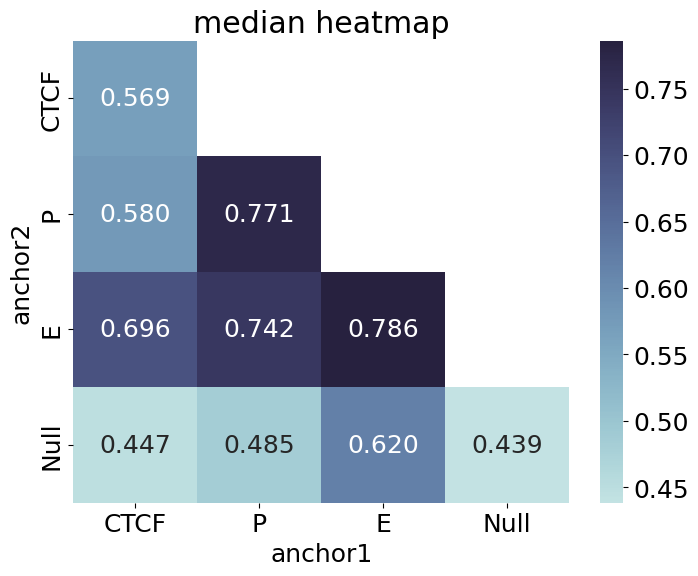

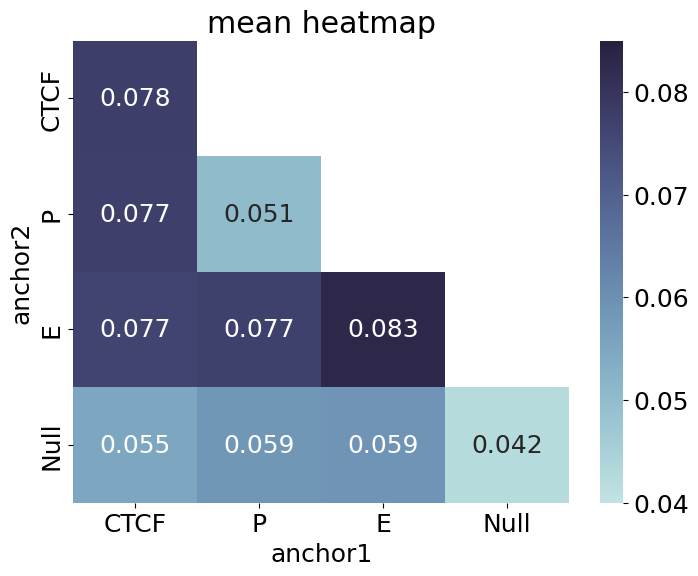

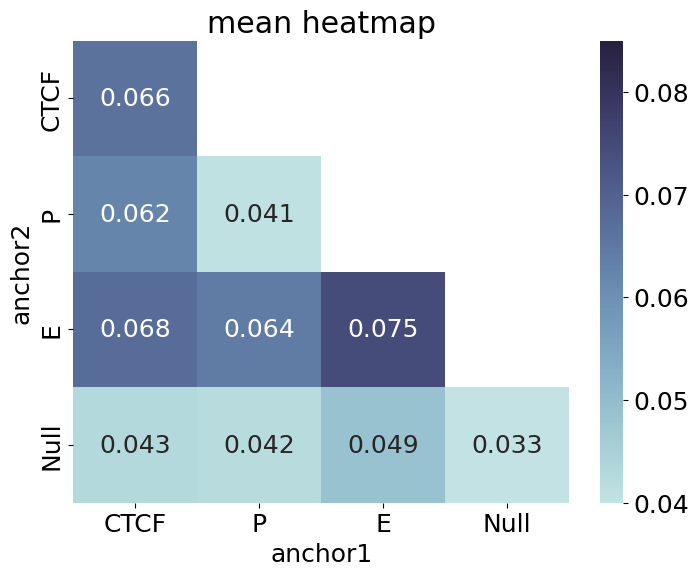

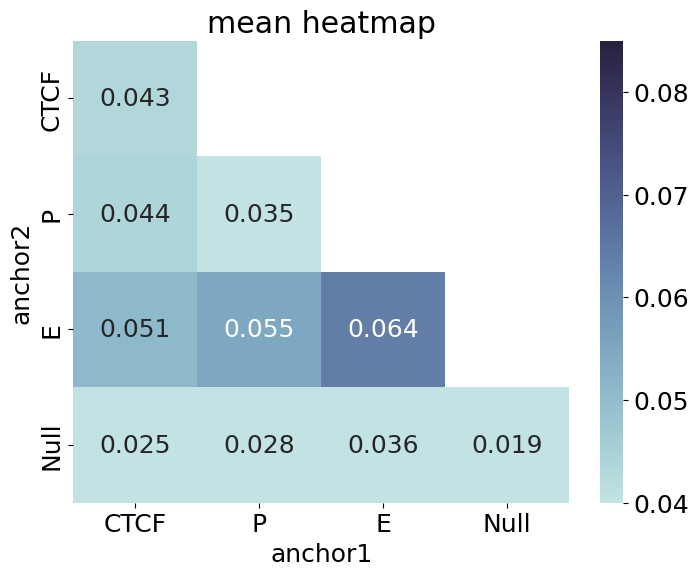

In [56]:
merged_loops = loop_strengths.merge(loop_classes, how='inner', left_on=['chr1','start1','end1','chr2','start2','end2'],
                                   right_on=['seqnames1','start1','end1','seqnames2','start2','end2'])
merged_loops.rename({'class':'pair'}, inplace=True, axis=1)
merged_loops['color'] = merged_loops['pair'].map(custom_colors)
merged_loops['FC_31'] = np.abs(merged_loops['strength_P3'].divide(merged_loops['strength_P1']))


plot_ls_heatmap(merged_loops, 'FC_31', fun='median', sd=savedir)
plot_ls_heatmap(merged_loops, 'strength_P1', valrange=(0.04, 0.085), fun='mean', sd=savedir)
plot_ls_heatmap(merged_loops, 'strength_P2', valrange=(0.04, 0.085), fun='mean', sd=savedir)
plot_ls_heatmap(merged_loops, 'strength_P3', valrange=(0.04, 0.085), fun='mean', sd=savedir)


032524_combined_DAP_JAN_028_ATAC_v1_both_classes.txt


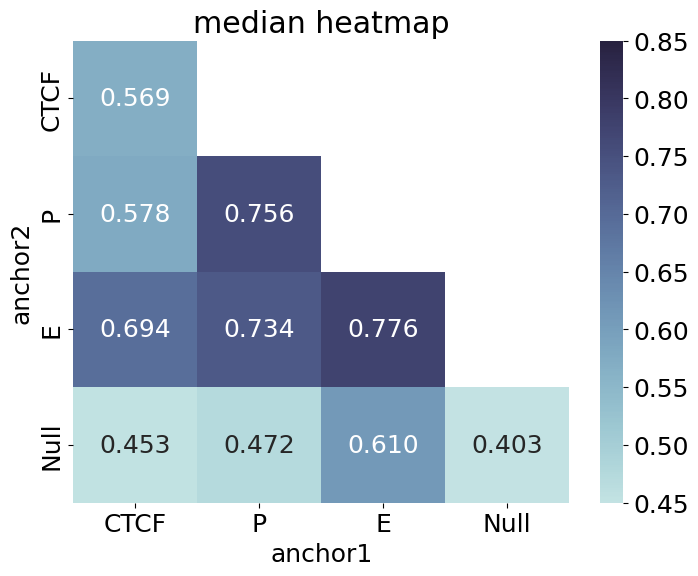

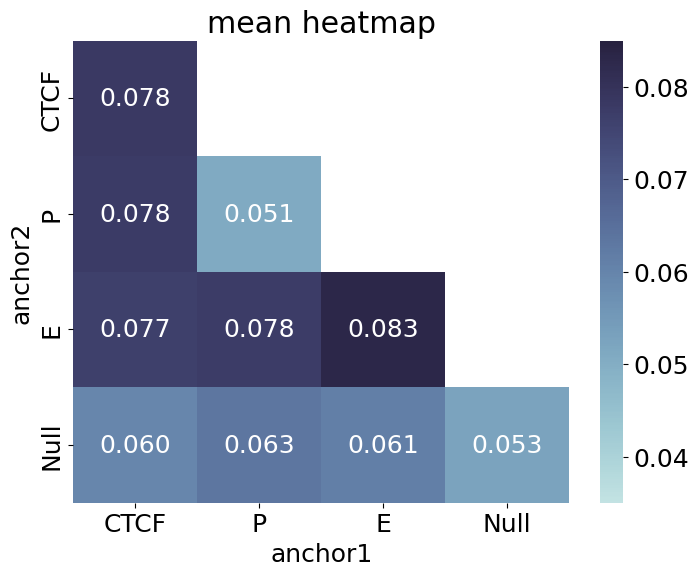

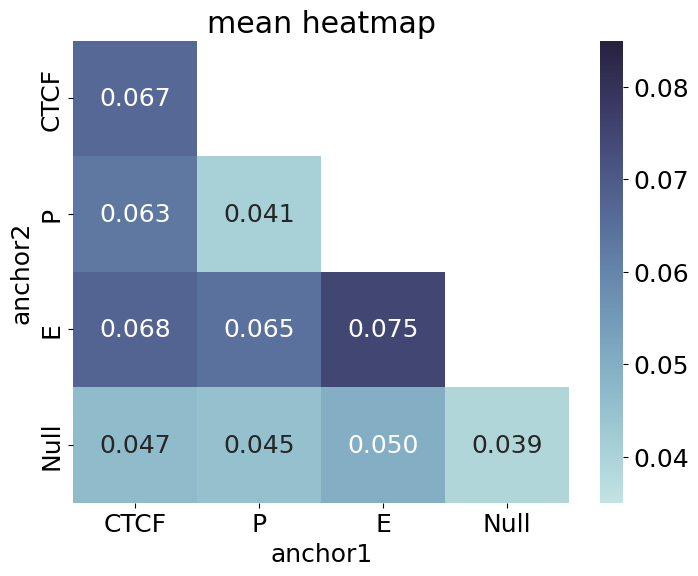

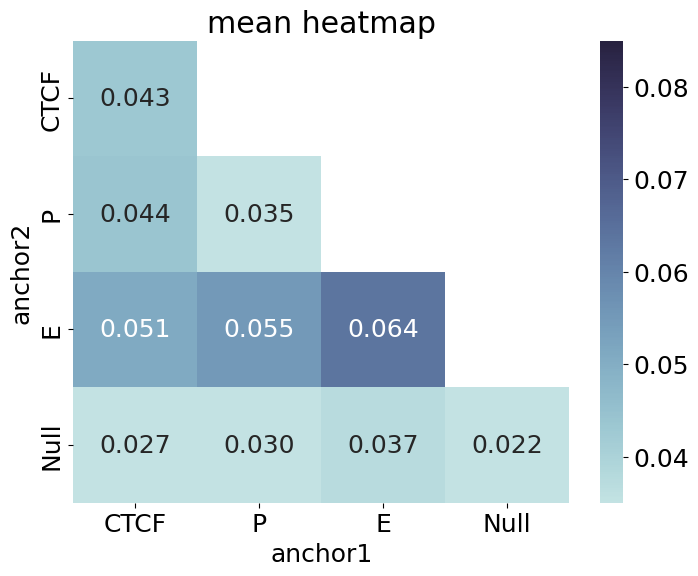

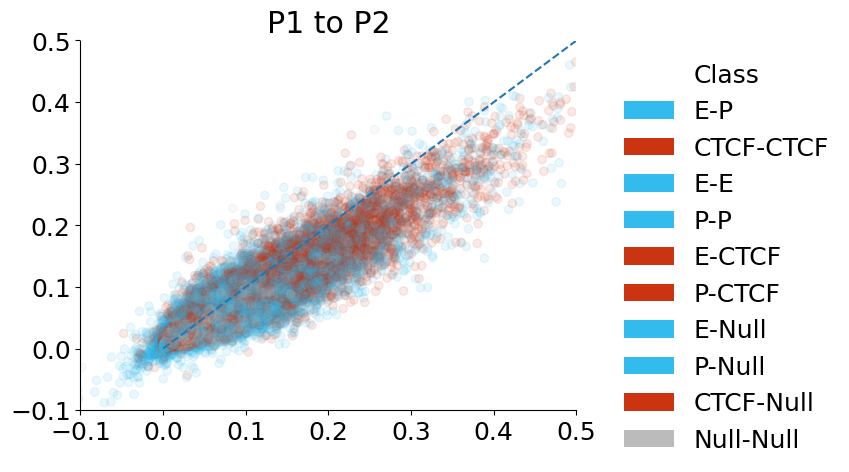

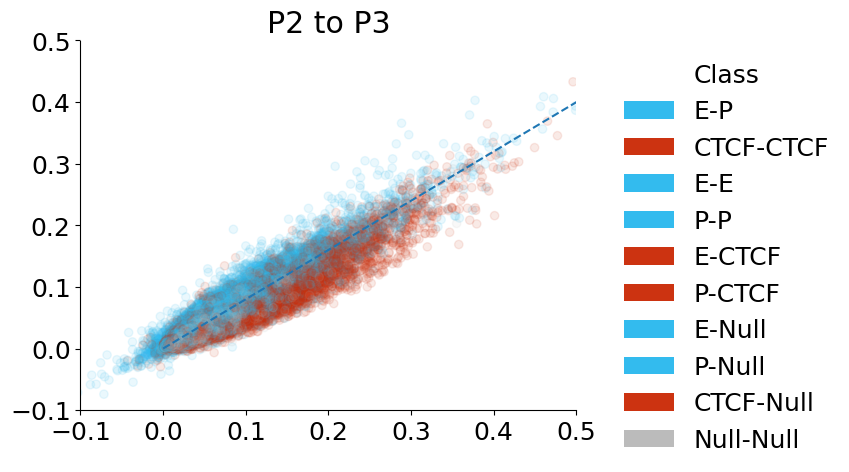

acrs_unique_v1_both_classes.txt


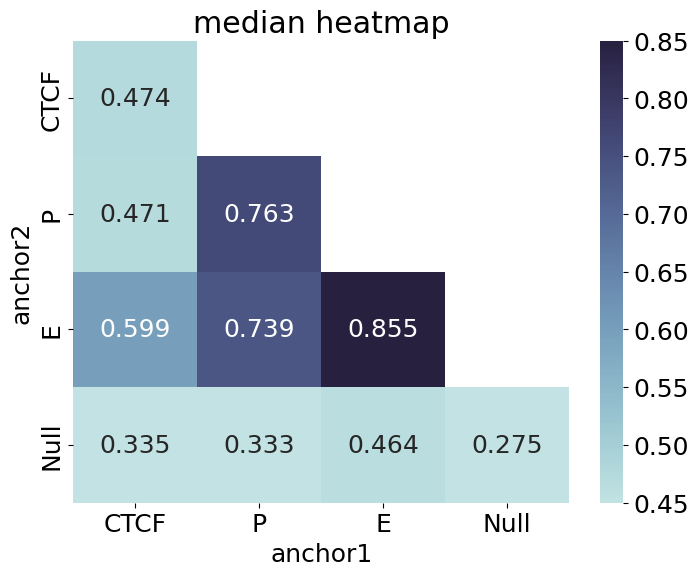

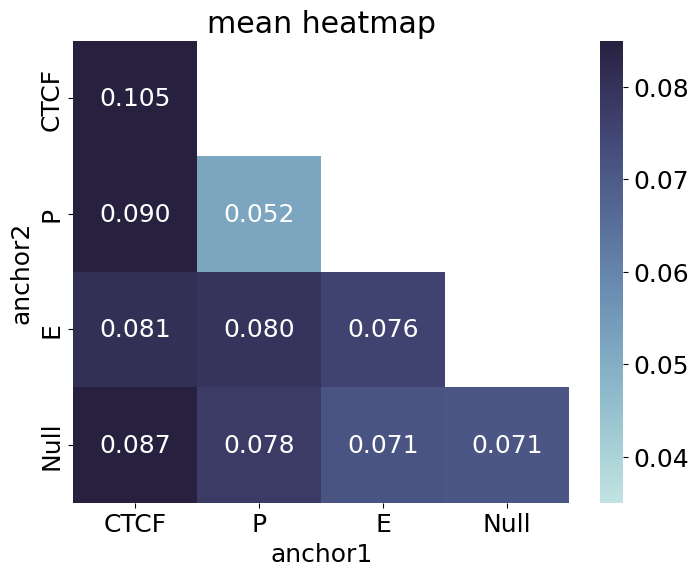

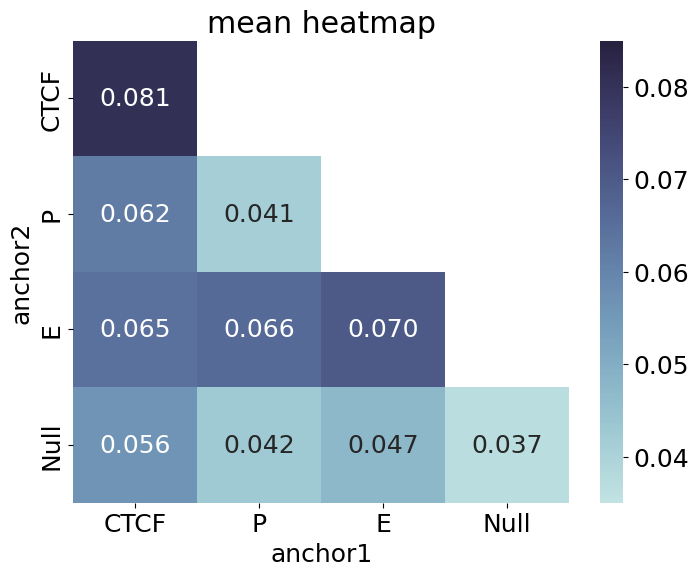

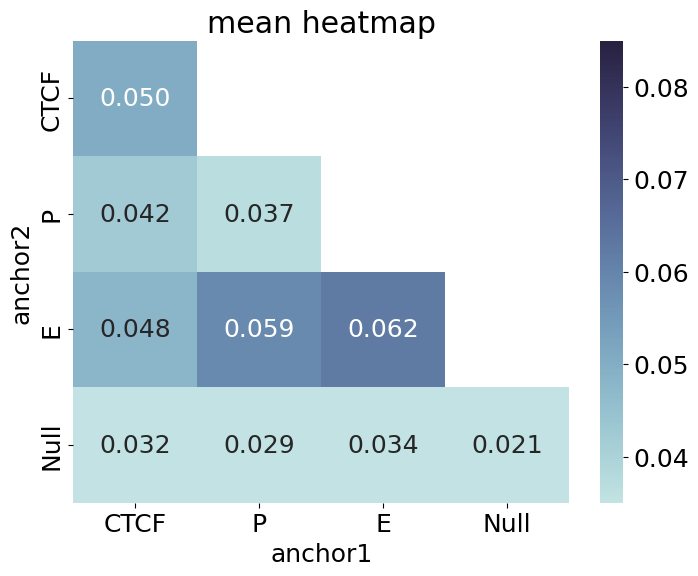

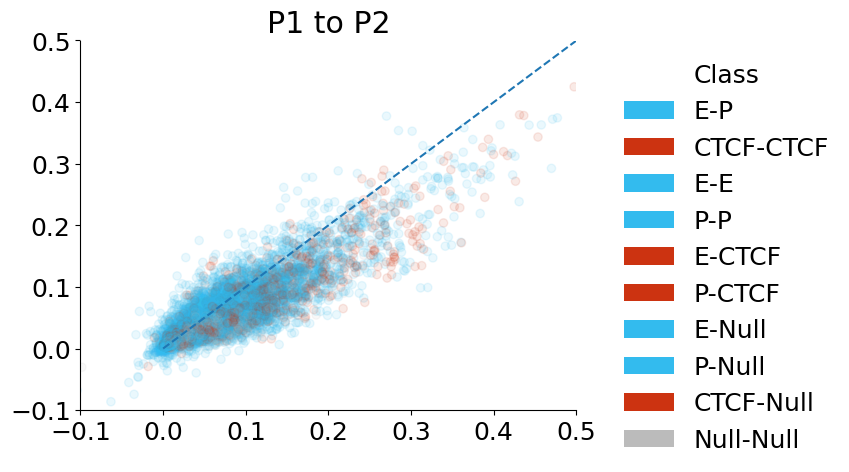

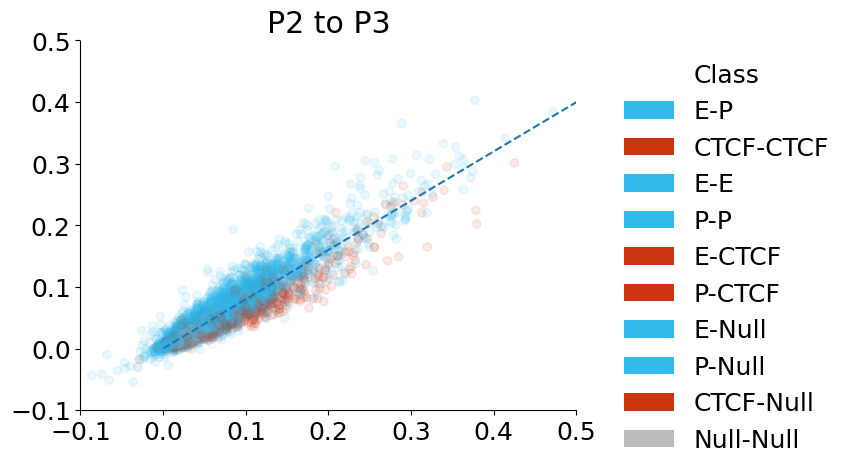

erythroid_tf_acrs_unique_v1_both_classes.txt


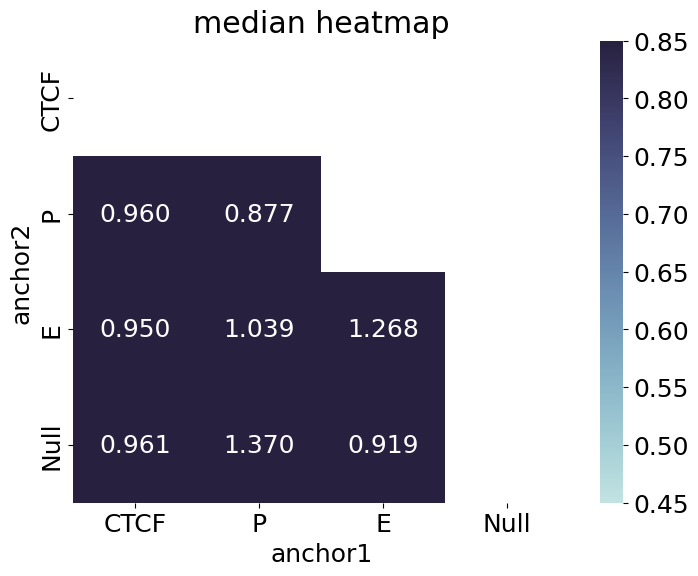

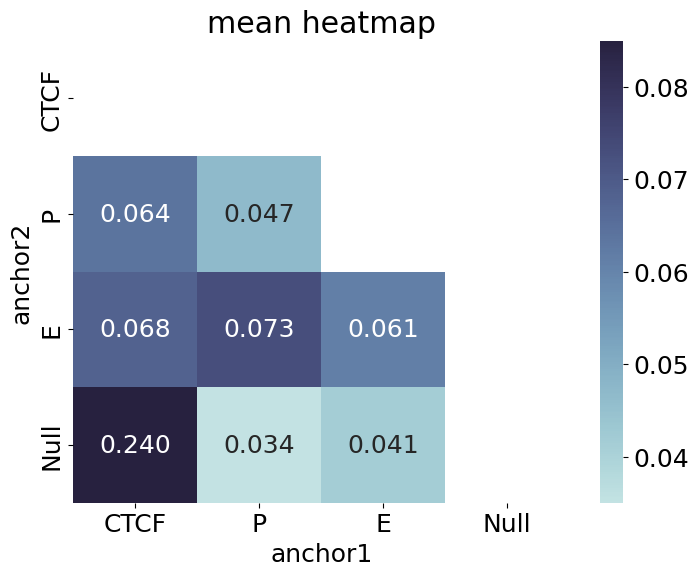

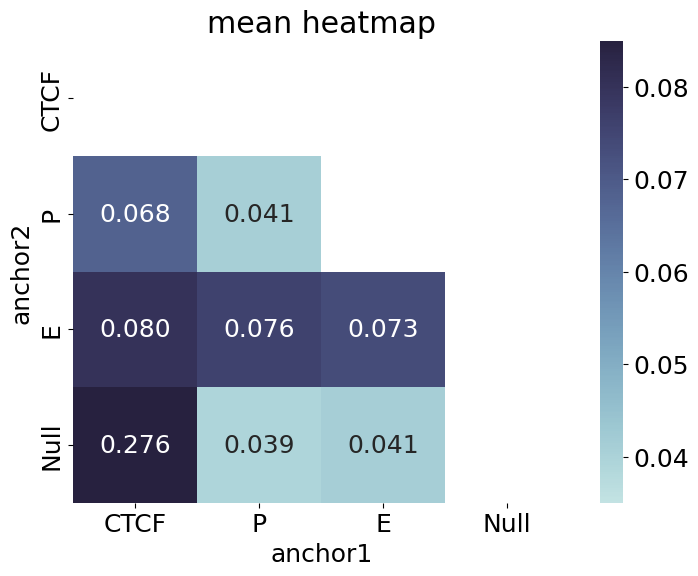

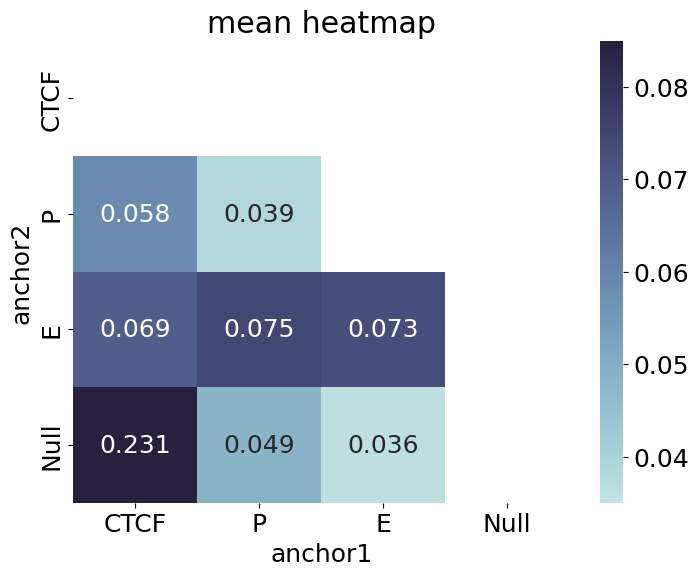

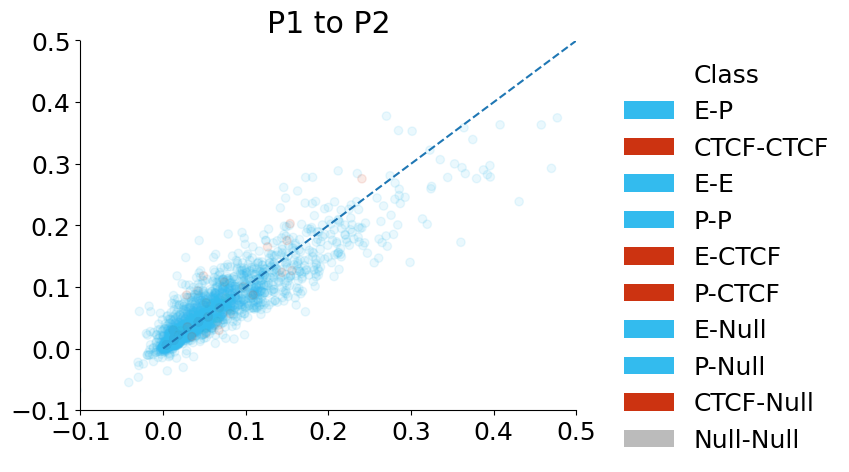

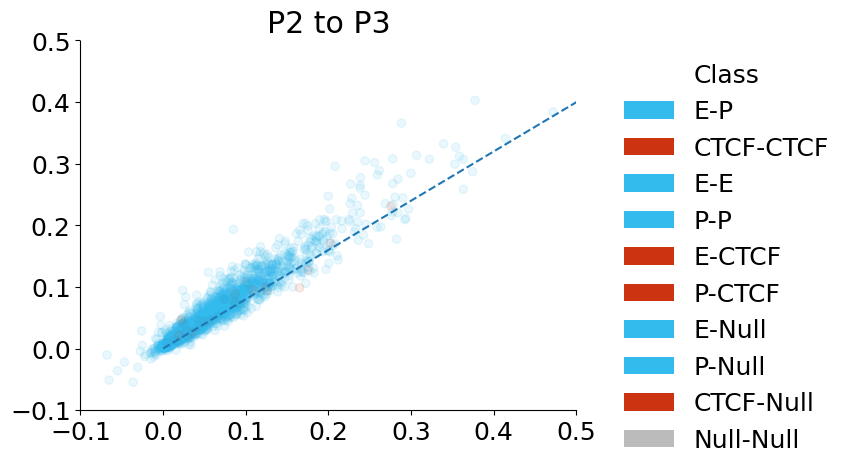

erythroid_associated_ACRs_v1_both_classes.txt


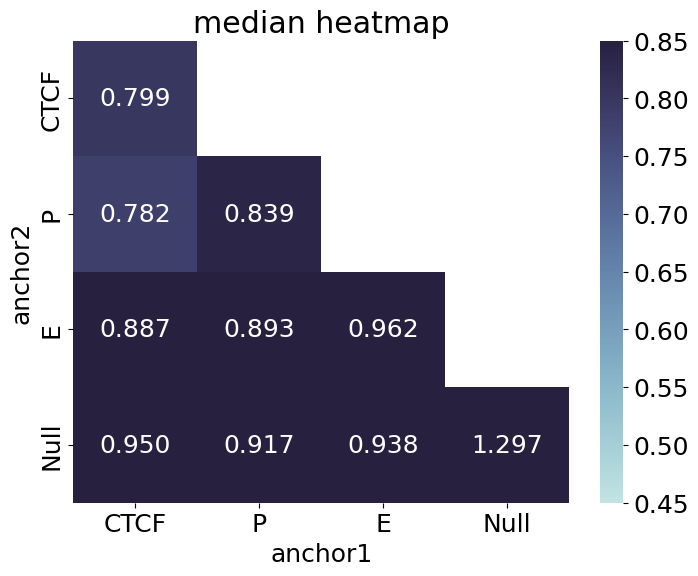

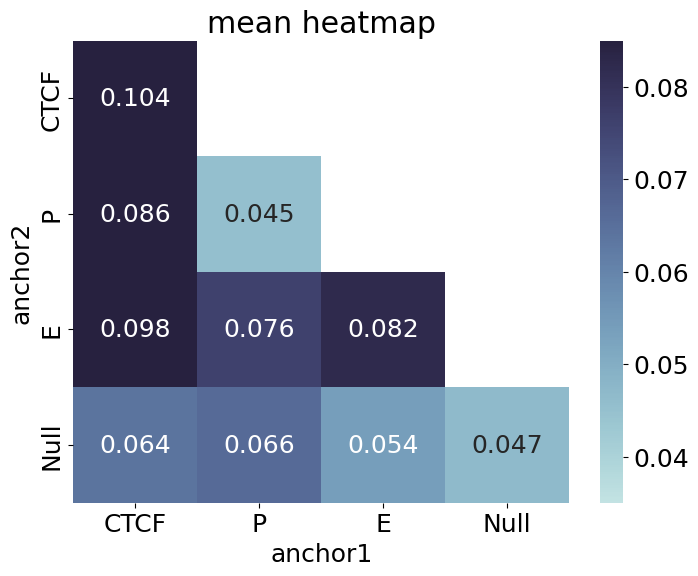

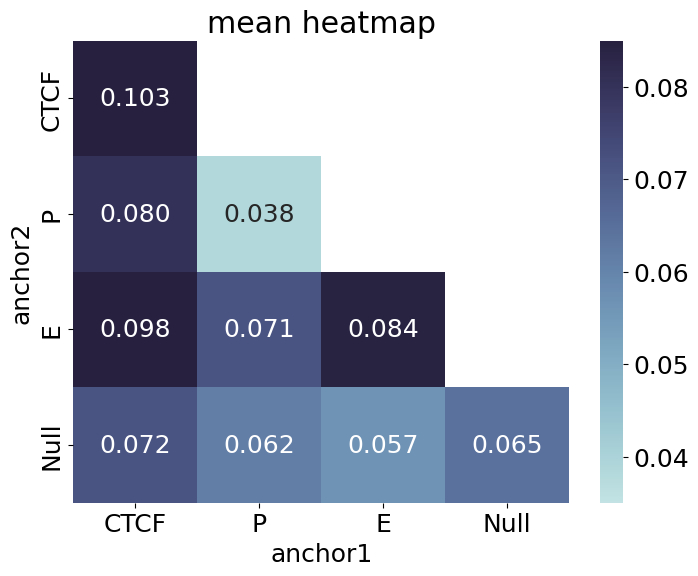

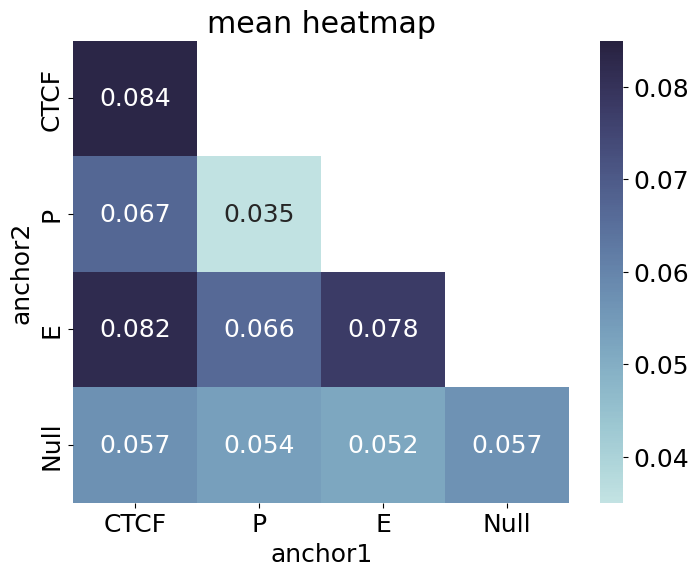

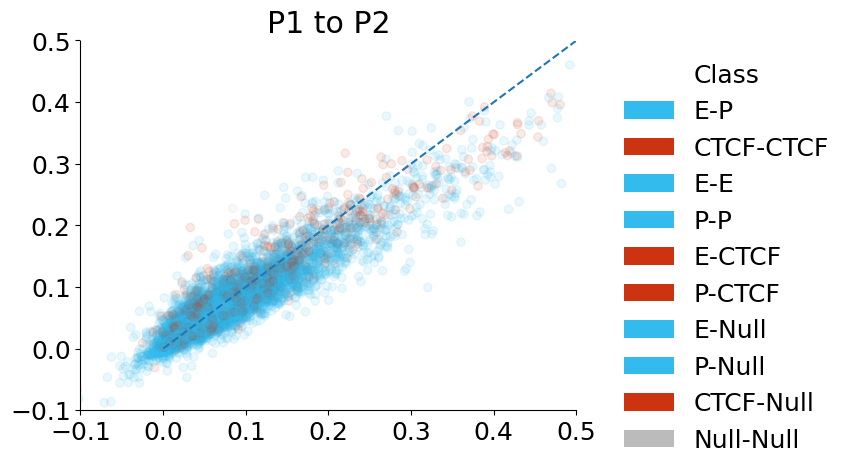

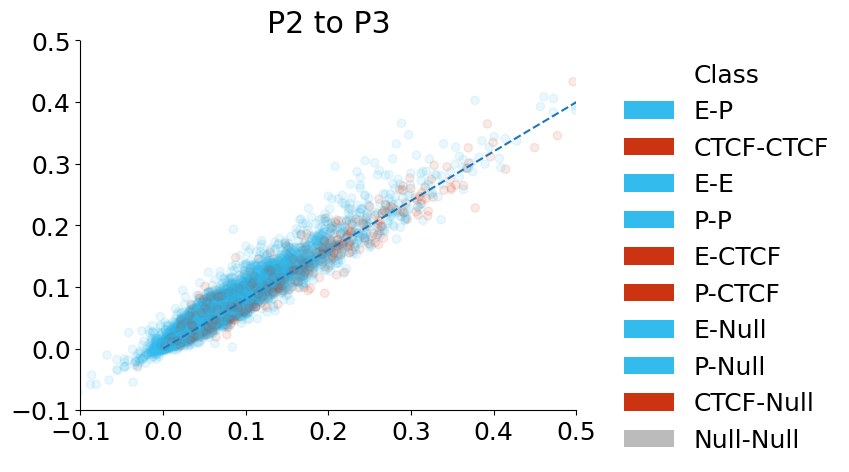

In [57]:
# now load the other loop files
# merge so that they have loop classes and strengths 
# repeat the plotting 

loopnames = [
    "032524_combined_DAP_JAN_028_ATAC_v1_both_classes.txt",
    "acrs_unique_v1_both_classes.txt",
    "erythroid_tf_acrs_unique_v1_both_classes.txt",
    "erythroid_associated_ACRs_v1_both_classes.txt"
]

all_grps = {}

for fname in loopnames:
    print(fname)
    df = pd.read_csv(os.path.join(basedir, fname), sep='\t')
    df[['start1','start2']] = df[['start1','start2']]-1
    
    df_merged = loop_strengths.merge(df, how='inner', left_on=['chr1','start1','end1','chr2','start2','end2'],
                                   right_on=['seqnames1','start1','end1','seqnames2','start2','end2'])
    
    df_merged['color'] = df_merged['pair'].map(custom_colors)
    df_merged['FC_31'] = df_merged['strength_P3'].divide(df_merged['strength_P1'])

    plot_ls_heatmap(df_merged, 'FC_31', valrange=(0.45, 0.85), sd=f"{savedir}{fname.split('_')[0]}")

    plot_ls_heatmap(df_merged, 'strength_P1', valrange=(0.035, 0.085), fun='mean')
    plot_ls_heatmap(df_merged, 'strength_P2', valrange=(0.035, 0.085), fun='mean')
    plot_ls_heatmap(df_merged, 'strength_P3', valrange=(0.035, 0.085), fun='mean')
    
    plt.figure()
    plt.scatter(df_merged['strength_P1'], df_merged['strength_P2'], color=df_merged['color'], alpha=0.1, rasterized=True)
    plt.plot(np.linspace(0, 1, 50), np.linspace(0, 1, 50), '--')
    plt.xlim([-0.1,0.5])
    plt.ylim([-0.1,0.5])
    plt.title('P1 to P2')
    plt.legend(handles=legend_elements, title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(f"{os.path.join(savedir,fname.split('classes')[0])}P12_scatter.svg")

    plt.show()

    plt.figure()
    plt.scatter(df_merged['strength_P2'], df_merged['strength_P3'], color=df_merged['color'], alpha=0.1, rasterized=True)
    plt.plot(np.linspace(0, 1, 50), np.linspace(0, 0.8, 50), '--')
    plt.xlim([-0.1,0.5])
    plt.ylim([-0.1,0.5])
    plt.title('P2 to P3')
    plt.legend(handles=legend_elements, title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(f"{os.path.join(savedir,fname.split('classes')[0])}P23_scatter.svg")
    plt.show()

    
    
    

In [11]:
PAIR_SUBCLASSES = {
    "CRE": [
        "E-E", "E-P", "P-P",
    ],
    "CTCF": [
        "CTCF-CTCF",
        "E-CTCF", "P-CTCF", 
    ],
    "CTCF_only": [
        "CTCF-CTCF"
    ]
}

def compute_log2_fold_change(df, percentile, subclass, phase1='P1', phase2='P3'):
    pair_subset = get_pairs_from_subclass(subclass)
    df_sub = df[df['pair'].isin(pair_subset)]

    fc = df_sub[f'strength_{phase2}'].divide(
        df_sub[f'strength_{phase1}']
    ).values

    # Remove non-positive values before log transform
    fc = fc[fc > 0]

    log2_fc = np.log2(fc)

    lower = np.nanpercentile(log2_fc, percentile)
    upper = np.nanpercentile(log2_fc, 100 - percentile)

    return log2_fc[(log2_fc > lower) & (log2_fc < upper)]

def get_pairs_from_subclass(subclass):
    if isinstance(subclass, list):
        return subclass
    if subclass not in PAIR_SUBCLASSES:
        raise ValueError(f"Subclass '{subclass}' not recognized.")
    return PAIR_SUBCLASSES[subclass]


def compute_fold_change(df, percentile, subclass, phase1='P1', phase2='P3'):
    pair_subset = get_pairs_from_subclass(subclass)
    df_sub = df[df['pair'].isin(pair_subset)]

    fc = df_sub[f'strength_{phase2}'].divide(
        df_sub[f'strength_{phase1}']
    ).values

    lower = np.nanpercentile(fc, percentile)
    upper = np.nanpercentile(fc, 100 - percentile)

    return fc[(fc > lower) & (fc < upper)]


def benjamini_hochberg(pvals):
    pvals = np.array(pvals)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = np.empty(n)

    for i, idx in enumerate(order):
        ranked[idx] = pvals[idx] * n / (i + 1)

        ranked_sorted = ranked[order]
    ranked_sorted = np.minimum.accumulate(ranked_sorted[::-1])[::-1]
    ranked[order] = ranked_sorted

    return np.minimum(ranked, 1.0)


def plot_violin_from_dict(
    datasets_dict,
    loop_strengths,
    merged_loops,
    basedir,
    subclass="CRE",
    percentile=5,
    phase1='P1',
    phase2='P3',
    sd=None
):

    phase_key = f"{phase2}/{phase1}"

    PHASE_COLORMAP = {
        "P2/P1": "#EE7733",
        "P3/P1": "#0077BB",
        "P3/P2": "#EE3377"
    }

    phase_color = PHASE_COLORMAP.get(phase_key, "#8172B2")

    records = []
    grouped_values = {}

    for title, path in datasets_dict.items():

        if path is not None:
            df = pd.read_csv(os.path.join(basedir, path), sep='\t').rename({'class':'pair'}, axis=1)
            df[['start1','start2']] -= 1

            df_merged = loop_strengths.merge(
                df,
                how='inner',
                left_on=['chr1','start1','end1','chr2','start2','end2'],
                right_on=['seqnames1','start1','end1','seqnames2','start2','end2']
            )

            fc = compute_log2_fold_change(
                df_merged, percentile, subclass, phase1, phase2
            )
        else:
            fc = compute_log2_fold_change(
                merged_loops, percentile, subclass, phase1, phase2
            )

        grouped_values[title] = fc

        for value in fc:
            records.append({
                "Dataset": title,
                "FoldChange": value
            })

    plot_df = pd.DataFrame(records)

    comparisons = list(itertools.combinations(grouped_values.keys(), 2))
    pvals = []

    for g1, g2 in comparisons:
        stat, p = mannwhitneyu(
            grouped_values[g1],
            grouped_values[g2],
            alternative='two-sided'
        )
        pvals.append(p)

    qvals = benjamini_hochberg(pvals)

    stats_df = pd.DataFrame({
        "Group1": [c[0] for c in comparisons],
        "Group2": [c[1] for c in comparisons],
        "p_value": pvals,
        "FDR_q": qvals
    })

    print("\nPairwise Mann-Whitney U results (BH corrected):")
    print(stats_df.sort_values("FDR_q"))


    plt.figure(figsize=(6, 6))
    ax = sns.violinplot(
        data=plot_df,
        x="Dataset",
        y="FoldChange",
        color=phase_color,
        inner="box"
    )

    plt.ylabel(f"{phase2}/{phase1} Fold Change in Loop Strength")
    plt.xlabel("Dataset")
    plt.title(f"Subclass: {subclass}")
    plt.xticks(rotation=30)
    plt.ylim(-2.75, 2.75)

    plt.tight_layout()
    print(plot_df.groupby('Dataset').agg('size'))
    if sd is not None:
        plt.savefig(sd)
    else:
        plt.show()

    return stats_df




Pairwise Mann-Whitney U results (BH corrected):
      Group1 Group2        p_value          FDR_q
3       ATAC    Ery  7.567603e-152  4.540562e-151
1  All Loops    Ery  1.136333e-148  3.409000e-148
4       ATAC  EryTF  1.327215e-128  2.654429e-128
2  All Loops  EryTF  5.954847e-127  8.932270e-127
5        Ery  EryTF   6.064685e-27   7.277621e-27
0  All Loops   ATAC   6.971360e-01   6.971360e-01
Dataset
ATAC         19474
All Loops    19743
Ery           9547
EryTF         2052
dtype: int64


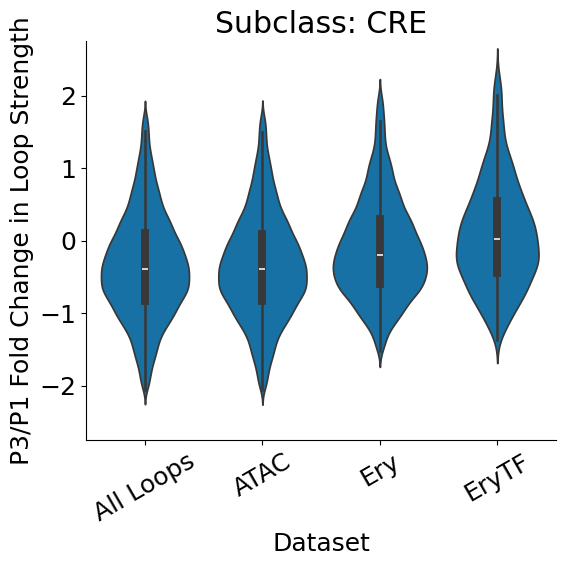

In [12]:
import itertools
from scipy.stats import mannwhitneyu

datasets = {
    'All Loops': None,
    'ATAC': os.path.join(basedir, "032524_combined_DAP_JAN_028_ATAC_v1_both_classes.txt"),
    'Ery': os.path.join(basedir, "erythroid_associated_ACRs_v1_both_classes.txt"),
    'EryTF': os.path.join(basedir, "erythroid_tf_acrs_unique_v1_both_classes.txt"),
}

out_cre = plot_violin_from_dict(
    datasets_dict=datasets,
    loop_strengths=loop_strengths,
    merged_loops=merged_loops,
    basedir=basedir,
    subclass="CRE",        
    percentile=2.5,
    sd = os.path.join('/mnt/md0/varshini/Analysis/Blood/figs_v2/fig2', 'p31_log2fc_loops_cre_types.svg')
)




Pairwise Mann-Whitney U results (BH corrected):
      Group1 Group2        p_value          FDR_q
3       ATAC    Ery  5.852803e-137  3.511682e-136
1  All Loops    Ery  2.067077e-136  6.201231e-136
4       ATAC  EryTF   7.824855e-81   1.564971e-80
2  All Loops  EryTF   2.277738e-80   3.416606e-80
5        Ery  EryTF   3.113610e-08   3.736332e-08
0  All Loops   ATAC   9.233103e-01   9.233103e-01

Pairwise Mann-Whitney U results (BH corrected):
      Group1 Group2       p_value         FDR_q
4       ATAC  EryTF  9.706421e-76  5.823852e-75
2  All Loops  EryTF  2.232145e-74  6.696434e-74
3       ATAC    Ery  4.112324e-57  8.224648e-57
1  All Loops    Ery  6.125174e-55  9.187761e-55
5        Ery  EryTF  1.796936e-23  2.156323e-23
0  All Loops   ATAC  6.737511e-01  6.737511e-01

Pairwise Mann-Whitney U results (BH corrected):
      Group1 Group2        p_value          FDR_q
1  All Loops    Ery  5.031603e-121  3.018962e-120
3       ATAC    Ery  2.449328e-120  7.347984e-120
2  All Loops  Ery

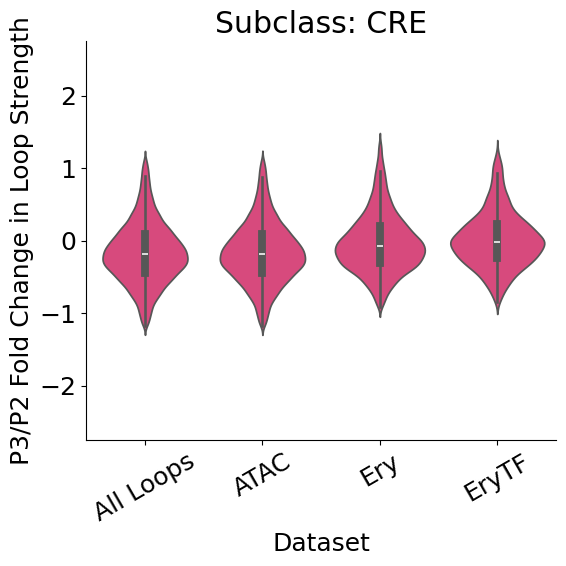

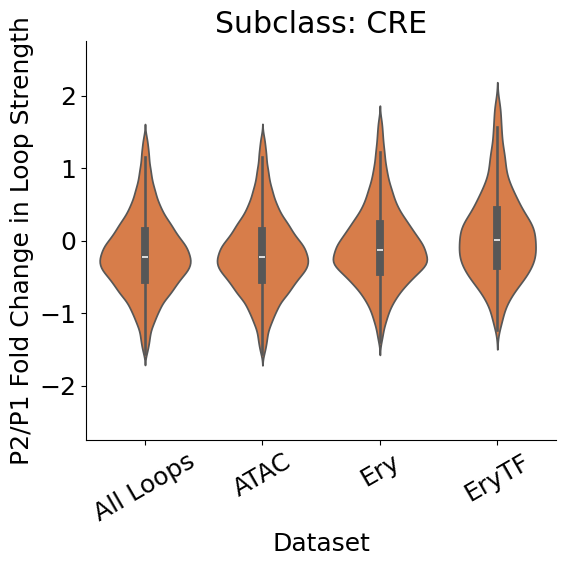

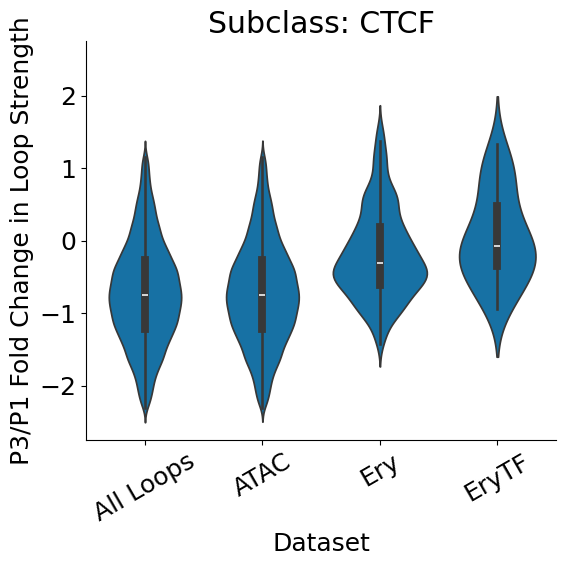

In [86]:

out_cre_32 = plot_violin_from_dict(
    datasets_dict=datasets,
    loop_strengths=loop_strengths,
    merged_loops=merged_loops,
    basedir=basedir,
    subclass="CRE",       
    percentile=2.5,
    phase1='P2',
    sd = os.path.join('/mnt/md0/varshini/Analysis/Blood/figs_v2/supp3', 'p32_log2fc_loops_cre_types.svg')
)

out_cre_21 = plot_violin_from_dict(
    datasets_dict=datasets,
    loop_strengths=loop_strengths,
    merged_loops=merged_loops,
    basedir=basedir,
    subclass="CRE",       
    percentile=2.5,
    phase2='P2',
    sd = os.path.join('/mnt/md0/varshini/Analysis/Blood/figs_v2/supp3','p21_log2fc_loops_cre_types.svg')
)

out_ctcf = plot_violin_from_dict(
    datasets_dict=datasets,
    loop_strengths=loop_strengths,
    merged_loops=merged_loops,
    basedir=basedir,
    subclass="CTCF",       
    percentile=2.5
)

In [ ]:
legend_elements = [
    Patch(facecolor=color, label=label) for label, color in custom_colors.items()
]

custom_colors = {'E-P':'#33BBEE',
                'CTCF-CTCF':'#CC3311',
                'E-E':'#009988',
                'P-P':'#0099BB',
                'E-CTCF':'#EE3377',
                'P-CTCF':'#EE7733',
                'E-Null':'#3377EE',
                'P-Null':'#008899',
                'CTCF-Null':'#CC1133',
                'Null-Null':'#BBBBBB'}
plt.figure(figsize=(10,8))


df = pd.read_csv(os.path.join(basedir, 'erythroid_tf_acrs_unique_loops_both_classes.txt'), sep='\t')
df[['start1','start2']] = df[['start1','start2']]-1
df_merged = loop_strengths.merge(df, how='inner', left_on=['chr1','start1','end1','chr2','start2','end2'],
                                   right_on=['seqnames1','start1','end1','seqnames2','start2','end2'])
df_merged['color'] = df_merged['pair'].map(custom_colors)   

merged_loops_sub = df_merged[(df_merged['pair'] == 'E-E') | (df_merged['pair'] == 'E-P') | (df_merged['pair'] == 'E-Null')]
toplot = merged_loops_sub['strength_P3'].divide(merged_loops_sub['strength_P1'])
toplot = toplot[(toplot>-5) & (toplot<5)]

merged_loops_sub_all = merged_loops[(merged_loops['pair'] == 'E-E') | (merged_loops['pair'] == 'E-P') | (merged_loops['pair'] == 'E-Null')]
toplot2 = merged_loops_sub_all['strength_P3'].divide(merged_loops_sub_all['strength_P1'])
toplot2 = toplot2[(toplot2>-5) & (toplot2<5)]
sns.histplot(toplot, bins=100, element='step', stat='density', fill=False)
sns.histplot(toplot2, bins=100, element='step', stat='density', fill=False)

plt.legend(loc='upper right', bbox_to_anchor=[1.15, 1])

# plt.ylim([0,2.5]) 
plt.xlim([-1, 3])
plt.ylabel('Density')
plt.xlabel('P3/P1 Fold Change in Loop Strength')
plt.show()

#plt.savefig(os.path.join(savedir, 'all_vs_tf_cres.svg'))

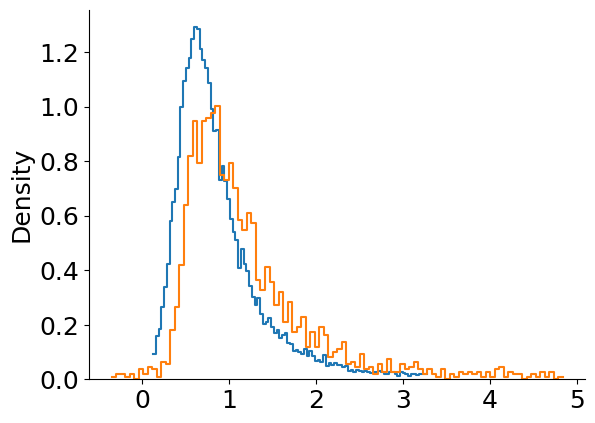

In [82]:

datasets = {
    'All Loops': None,
    'EryTF': os.path.join(basedir, "erythroid_tf_acrs_unique_v1_both_classes.txt"),
}

plt.figure()
for title, path in datasets.items():

    if path is not None:
        df = pd.read_csv(os.path.join(basedir, path), sep='\t').rename({'class':'pair'}, axis=1)
        df[['start1','start2']] -= 1

        df_merged = loop_strengths.merge(
            df,
            how='inner',
            left_on=['chr1','start1','end1','chr2','start2','end2'],
            right_on=['seqnames1','start1','end1','seqnames2','start2','end2']
        )
        fc = compute_fold_change(
                df_merged, 2.5, "CRE", 'P1', 'P3'
            )
    
    else:
        fc = compute_fold_change(
                merged_loops, 2.5, "CRE", 'P1', 'P3'
        )
    sns.histplot(fc, bins=100, element='step', stat='density', fill=False)
        
plt.show()